# Static-surprise dRSA and cross-temporal regression

This notebook treats the difference between the 2250 ms static-image response and the standard static response to the matching movie final frame as a time-resolved surprise signal.

For stimulus $i$ and static-response time $\tau$:

$$\Delta x_i(\tau) = x_i^{2250\,\mathrm{ms}}(\tau) - x_i^{\mathrm{final}}(\tau).$$

Two complementary analyses use the same `movie time × surprise time` layout:

1. **Surprise dRSA:** compare movie RDMs with RDMs constructed from the multichannel $\Delta x_i(\tau)$ patterns.
2. **Surprise regression:** use either the raw signed delta pattern or its scalar magnitude to predict movie population responses across stimuli at every movie timepoint.

In [1]:
from dataclasses import dataclass
from pathlib import Path
from time import perf_counter
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Locate the repository whether Jupyter starts in the project root or scripts folder.
PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "config.yaml").exists()
)
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from project_specific_utils import (
    cross_temporal_static_dynamic_regression,
    load_natraster,
    match_timed_static_movie_rasters,
    min_max_normalization,
)
from useful_stuff.general_utils import TimeSeries
from useful_stuff.general_utils.RSA import dRSA


In [9]:
@dataclass
class Cfg:
    vid_exp_name: str = "red_20260720to24" # "baby1_260716to24" #
    img_exp_name: str = "red_20260726" #"baby1_260718to26" # #
    image_prefix: str = "img_"
    image_2000ms_prefix: str = "img_2000ms_"
    image_2250ms_prefix: str = "img_2250ms_"
    movie_prefix: str = "vid_"

    # MATLAB channels are inclusive; the Python slice below converts accordingly.
    good_channels: tuple[int, int] | None = None #(101, 109) #(84, 186)
    top_k: int | None = 10 #None  # Used only when good_channels is None.
    new_fs: float | None = 100
    normalization: str | None = None  # Supported: None or "min_max".

    movie_RDM_metric: str = "cosine_cnt"
    surprise_RDM_metric: str = "cosine_cnt"
    RSA_metric: str = "correlation"

    regression_type: str = "ridge"
    regression_cv_type: str = "kf"  # Use "same" for in-sample fits.
    regression_score_type: str = "corr"  # Supported: "corr" or "r2".
    regression_n_splits: int = 3
    regression_shuffle: bool = False
    regression_alphas: tuple[float, ...] = (
        1e-6, 1e-4, 1e-2, 1, 1e2, 1e4,
    )
    regression_fit_intercept: bool = True

    # Keep both at 1 for the complete-resolution matrices. Larger values speed up development runs by taking every nth timepoint.
    surprise_time_stride: int = 1
    movie_time_stride: int = 1
    movie_final_frame_ms: float = 2500
    linewidth: float = 3


cfg = Cfg()
cfg


Cfg(vid_exp_name='red_20260720to24', img_exp_name='red_20260726', image_prefix='img_', image_2000ms_prefix='img_2000ms_', image_2250ms_prefix='img_2250ms_', movie_prefix='vid_', good_channels=None, top_k=10, new_fs=100, normalization=None, movie_RDM_metric='cosine_cnt', surprise_RDM_metric='cosine_cnt', RSA_metric='correlation', regression_type='ridge', regression_cv_type='kf', regression_score_type='corr', regression_n_splits=3, regression_shuffle=False, regression_alphas=(1e-06, 0.0001, 0.01, 1, 100.0, 10000.0), regression_fit_intercept=True, surprise_time_stride=1, movie_time_stride=1, movie_final_frame_ms=2500, linewidth=3)

## Load and align the four stimulus conditions

The alignment retains only identities present in the standard image, 2000 ms image, 2250 ms image, and movie conditions. This guarantees that the stimulus axis has the same identity and order everywhere. The 2000 ms condition is retained by the loader for alignment checks but is not used in the surprise definition below.

In [10]:
video_mat_path = (
    Path(paths["data_path"]) / "data"
    / f"{cfg.vid_exp_name}_natraster.mat"
)
image_mat_path = (
    Path(paths["data_path"]) / "data"
    / f"{cfg.img_exp_name}_natraster.mat"
)

loaded_movie_rasters, movie_stimulus_names = load_natraster(video_mat_path)
loaded_image_rasters, image_stimulus_names = load_natraster(image_mat_path)

(
    final_static_rasters,
    movie_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    aligned_names,
) = match_timed_static_movie_rasters(
    loaded_image_rasters,
    image_stimulus_names,
    loaded_movie_rasters,
    movie_stimulus_names,
    image_prefix=cfg.image_prefix,
    image_2000ms_prefix=cfg.image_2000ms_prefix,
    image_2250ms_prefix=cfg.image_2250ms_prefix,
    movie_prefix=cfg.movie_prefix,
)

if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    channel_indices = slice(first_channel - 1, last_channel)
elif cfg.top_k is not None:
    # Rank channels by their maximum movie response over time and stimuli.
    channel_scores = movie_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_scores)[-cfg.top_k:][::-1]
else:
    channel_indices = slice(None)
# end if cfg.good_channels is not None

final_static_ts = TimeSeries(
    final_static_rasters[channel_indices], fs=1000,
)
image_2000ms_ts = TimeSeries(
    image_2000ms_rasters[channel_indices], fs=1000,
)
image_2250ms_ts = TimeSeries(
    image_2250ms_rasters[channel_indices], fs=1000,
)
movie_ts = TimeSeries(movie_rasters[channel_indices], fs=1000)

if cfg.new_fs is not None:
    final_static_ts.resample(cfg.new_fs)
    image_2000ms_ts.resample(cfg.new_fs)
    image_2250ms_ts.resample(cfg.new_fs)
    movie_ts.resample(cfg.new_fs)
# end if cfg.new_fs is not None

if cfg.normalization == "min_max":
    normalization_reference = np.concatenate([
        final_static_ts.get_array().reshape(final_static_ts.shape()[0], -1),
        image_2250ms_ts.get_array().reshape(image_2250ms_ts.shape()[0], -1),
        movie_ts.get_array().reshape(movie_ts.shape()[0], -1),
    ], axis=1)
    for response_ts in (final_static_ts, image_2250ms_ts, movie_ts):
        response_ts.set_array(min_max_normalization(
            response_ts.get_array(),
            reference_data=normalization_reference,
        ))
    # end for response_ts
elif cfg.normalization is not None:
    raise ValueError(
        f"Unsupported normalization: {cfg.normalization!r}."
    )
# end if cfg.normalization == "min_max"

print(f"Aligned stimuli: {len(shared_stimuli)}")
print(f"Final-frame static response: {final_static_ts.shape()}")
print(f"2250 ms static response: {image_2250ms_ts.shape()}")
print(f"Movie response: {movie_ts.shape()}")


Aligned stimuli: 100
Final-frame static response: (10, 100, 100)
2250 ms static response: (10, 100, 100)
Movie response: (10, 350, 100)


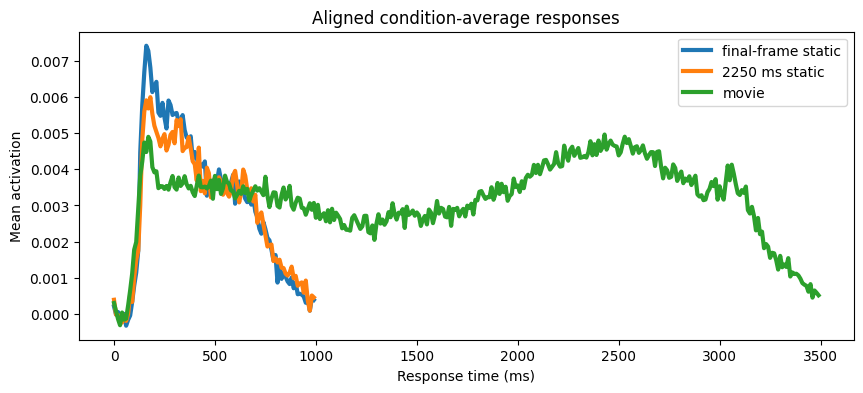

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
final_time_ms = (
    np.arange(len(final_static_ts)) * 1000 / final_static_ts.get_fs()
)
movie_time_ms = np.arange(len(movie_ts)) * 1000 / movie_ts.get_fs()
ax.plot(
    final_time_ms,
    final_static_ts.get_array().mean(axis=(0, 2)),
    label="final-frame static",
    linewidth=cfg.linewidth,
)
ax.plot(
    final_time_ms,
    image_2250ms_ts.get_array().mean(axis=(0, 2)),
    label="2250 ms static",
    linewidth=cfg.linewidth,
)
ax.plot(
    movie_time_ms,
    movie_ts.get_array().mean(axis=(0, 2)),
    label="movie",
    linewidth=cfg.linewidth,
)
ax.set_xlabel("Response time (ms)")
ax.set_ylabel("Mean activation")
ax.set_title("Aligned condition-average responses")
ax.legend()


## Construct the time-resolved surprise response

The subtraction is performed elementwise after alignment, preserving `channels × static time × stimuli`. The signed delta retains which channels increase or decrease. Its L2 magnitude collapses channels and retains only the overall size of the condition difference for each stimulus and timepoint.

In [12]:
if final_static_ts.shape() != image_2250ms_ts.shape():
    raise ValueError(
        "The 2250 ms and final-frame static responses must have identical "
        "channels, timepoints, and stimuli before subtraction."
    )
# end if final_static_ts.shape() != image_2250ms_ts.shape()
if final_static_ts.get_fs() != image_2250ms_ts.get_fs():
    raise ValueError("Static responses have different sampling rates.")
# end if final_static_ts.get_fs()

surprise_delta_array = (
    image_2000ms_ts.get_array() - final_static_ts.get_array()
)
surprise_delta_ts = TimeSeries(
    surprise_delta_array,
    fs=final_static_ts.get_fs(),
)
surprise_magnitude_ts = TimeSeries(
    np.linalg.norm(surprise_delta_array, axis=0, keepdims=True),
    fs=final_static_ts.get_fs(),
)

surprise_time_ms = (
    np.arange(len(surprise_delta_ts))
    * 1000 / surprise_delta_ts.get_fs()
)
print(f"Signed surprise delta: {surprise_delta_ts.shape()}")
print(f"L2 surprise magnitude: {surprise_magnitude_ts.shape()}")


Signed surprise delta: (10, 100, 100)
L2 surprise magnitude: (1, 100, 100)


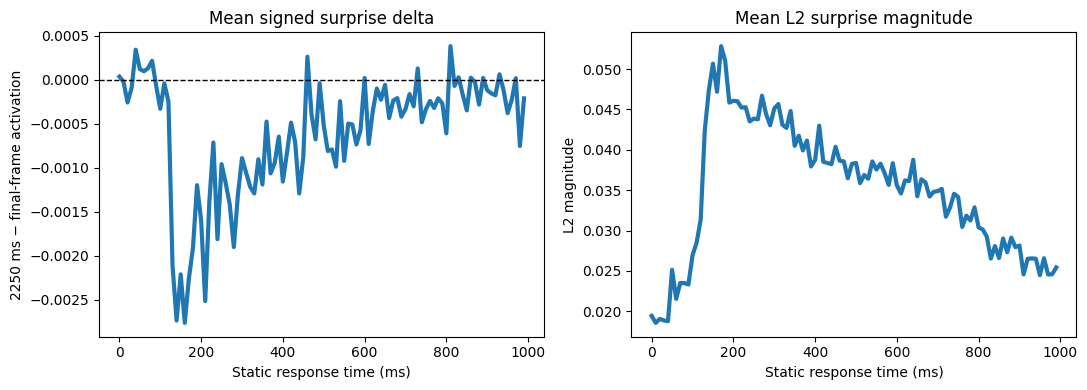

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(
    surprise_time_ms,
    surprise_delta_array.mean(axis=(0, 2)),
    linewidth=cfg.linewidth,
)
ax[0].axhline(0, color="black", linestyle="--", linewidth=1)
ax[0].set_title("Mean signed surprise delta")
ax[0].set_xlabel("Static response time (ms)")
ax[0].set_ylabel("2250 ms − final-frame activation")

ax[1].plot(
    surprise_time_ms,
    surprise_magnitude_ts.get_array().mean(axis=(0, 2)),
    linewidth=cfg.linewidth,
)
ax[1].set_title("Mean L2 surprise magnitude")
ax[1].set_xlabel("Static response time (ms)")
ax[1].set_ylabel("L2 magnitude")
fig.tight_layout()


## Surprise-pattern dRSA

At every static-response time $\tau$, the surprise RDM is

$$RDM_{\mathrm{surprise}}(i,j,\tau) = d\!\left(\Delta x_i(\tau),\Delta x_j(\tau)\right).$$

The `dRSA` class constructs the movie and surprise RDM time series and correlates every pair. Rows are movie-response timepoints; columns are surprise-response timepoints.

In [15]:
surprise_drsa = dRSA(
    signal_RDM_metric=cfg.movie_RDM_metric,
    model_RDM_metric=cfg.surprise_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)
surprise_drsa.compute_both_RDM_timeseries(movie_ts, surprise_delta_ts)
surprise_drsa_matrix = surprise_drsa.compute_dRSA()
surprise_RDM_timeseries = surprise_drsa.get_RDM_timeseries("model")

print(
    f"Surprise dRSA: {surprise_drsa_matrix.shape} "
    "(movie time, surprise time)"
)


Surprise dRSA: (350, 100) (movie time, surprise time)


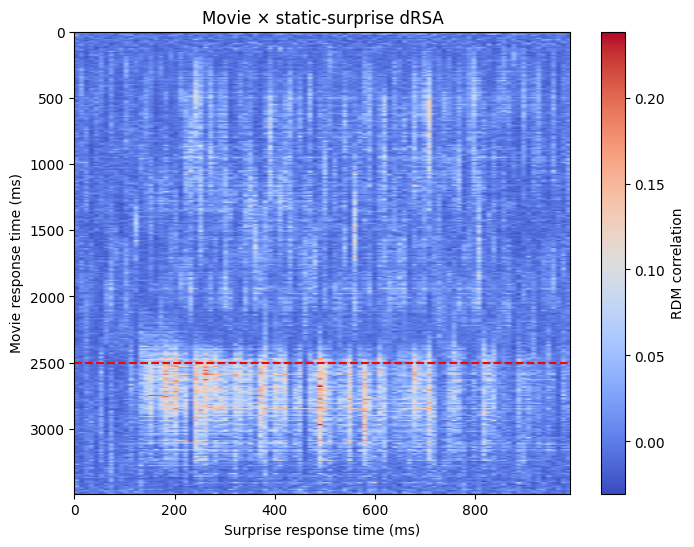

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    surprise_drsa_matrix,
    aspect="auto",
    origin="upper",
    cmap="coolwarm",
    extent=[
        surprise_time_ms[0], surprise_time_ms[-1],
        movie_time_ms[-1], movie_time_ms[0],
    ],
)
if movie_time_ms[0] <= cfg.movie_final_frame_ms <= movie_time_ms[-1]:
    ax.axhline(
        cfg.movie_final_frame_ms, color="red", linestyle="--",
    )
# end if cfg.movie_final_frame_ms
ax.set_title("Movie × static-surprise dRSA")
ax.set_xlabel("Surprise response time (ms)")
ax.set_ylabel("Movie response time (ms)")
fig.colorbar(image, ax=ax, label="RDM correlation")


## Cross-temporal surprise regression

Every matrix cell is fitted independently. For a fixed surprise time $\tau$ and movie time $t$, a separate `dyn_linear_encoding` model learns

$$Y_{movie}(t) = B_{t,\tau}\,\Delta X(\tau) + b_{t,\tau}.$$

The implementation calls `crossvalidate_static_dyn` for each surprise time. That class method then calls `crossvalidate` separately for every movie time, so weights, intercepts, and ridge selection are not shared across rows or columns. The resulting matrix has movie time on rows and surprise time on columns, matching the dRSA layout.

With `regression_score_type="corr"`, each entry is the mean held-out correlation between predicted and measured movie channel patterns. With `"r2"`, it is the mean held-out channel-wise $R^2$. The raw-delta model retains sign and magnitude; the magnitude-only model tests whether a single response-strength value is sufficient.

At full resolution this requires one independent regression for each of `350 × 100 = 35,000` timepoint pairs, multiplied by the number of cross-validation folds. Increase the two time-stride parameters for fast development runs.

In [9]:
# Optional time strides reduce computation while preserving explicit time axes.
regression_delta_ts = TimeSeries(
    surprise_delta_ts.get_array()[:, ::cfg.surprise_time_stride, :],
    fs=surprise_delta_ts.get_fs() / cfg.surprise_time_stride,
)
regression_magnitude_ts = TimeSeries(
    surprise_magnitude_ts.get_array()[:, ::cfg.surprise_time_stride, :],
    fs=surprise_magnitude_ts.get_fs() / cfg.surprise_time_stride,
)
regression_movie_ts = TimeSeries(
    movie_ts.get_array()[:, ::cfg.movie_time_stride, :],
    fs=movie_ts.get_fs() / cfg.movie_time_stride,
)
regression_surprise_time_ms = (
    np.arange(len(regression_delta_ts))
    * 1000 / regression_delta_ts.get_fs()
)
regression_movie_time_ms = (
    np.arange(len(regression_movie_ts))
    * 1000 / regression_movie_ts.get_fs()
)


In [ ]:
start_time = perf_counter()
raw_delta_regression_matrix = cross_temporal_static_dynamic_regression(
    regression_delta_ts,
    regression_movie_ts,
    regression_type=cfg.regression_type,
    cv_type=cfg.regression_cv_type,
    score_type=cfg.regression_score_type,
    n_splits=cfg.regression_n_splits,
    shuffle=cfg.regression_shuffle,
    alphas=cfg.regression_alphas,
    fit_intercept=cfg.regression_fit_intercept,
)
print(
    f"Raw-delta regression: {raw_delta_regression_matrix.shape}; "
    f"elapsed {perf_counter() - start_time:.1f} s"
)


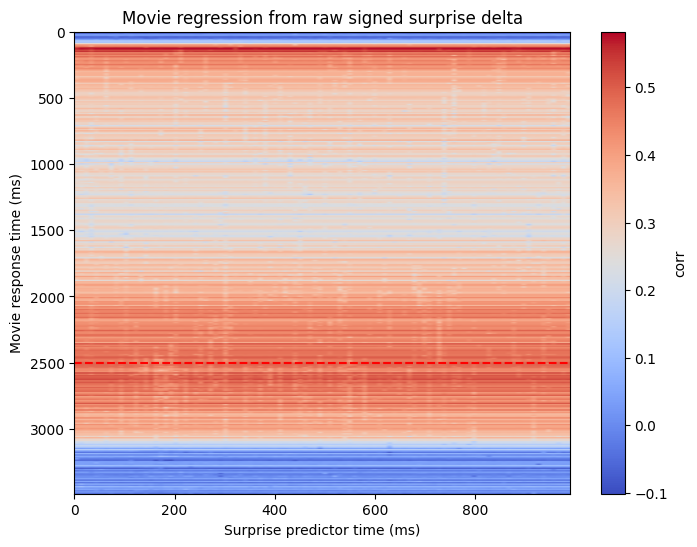

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    raw_delta_regression_matrix,
    aspect="auto",
    origin="upper",
    cmap="coolwarm",
    extent=[
        regression_surprise_time_ms[0],
        regression_surprise_time_ms[-1],
        regression_movie_time_ms[-1],
        regression_movie_time_ms[0],
    ],
)
if (
        regression_movie_time_ms[0]
        <= cfg.movie_final_frame_ms
        <= regression_movie_time_ms[-1]
        ):
    ax.axhline(
        cfg.movie_final_frame_ms, color="red", linestyle="--",
    )
# end if cfg.movie_final_frame_ms
ax.set_title("Movie regression from raw signed surprise delta")
ax.set_xlabel("Surprise predictor time (ms)")
ax.set_ylabel("Movie response time (ms)")
fig.colorbar(image, ax=ax, label=cfg.regression_score_type)


In [ ]:
start_time = perf_counter()
magnitude_regression_matrix = cross_temporal_static_dynamic_regression(
    regression_magnitude_ts,
    regression_movie_ts,
    regression_type=cfg.regression_type,
    cv_type=cfg.regression_cv_type,
    score_type=cfg.regression_score_type,
    n_splits=cfg.regression_n_splits,
    shuffle=cfg.regression_shuffle,
    alphas=cfg.regression_alphas,
    fit_intercept=cfg.regression_fit_intercept,
)
print(
    f"Magnitude regression: {magnitude_regression_matrix.shape}; "
    f"elapsed {perf_counter() - start_time:.1f} s"
)


Magnitude regression: (350, 100); elapsed 75.5 s


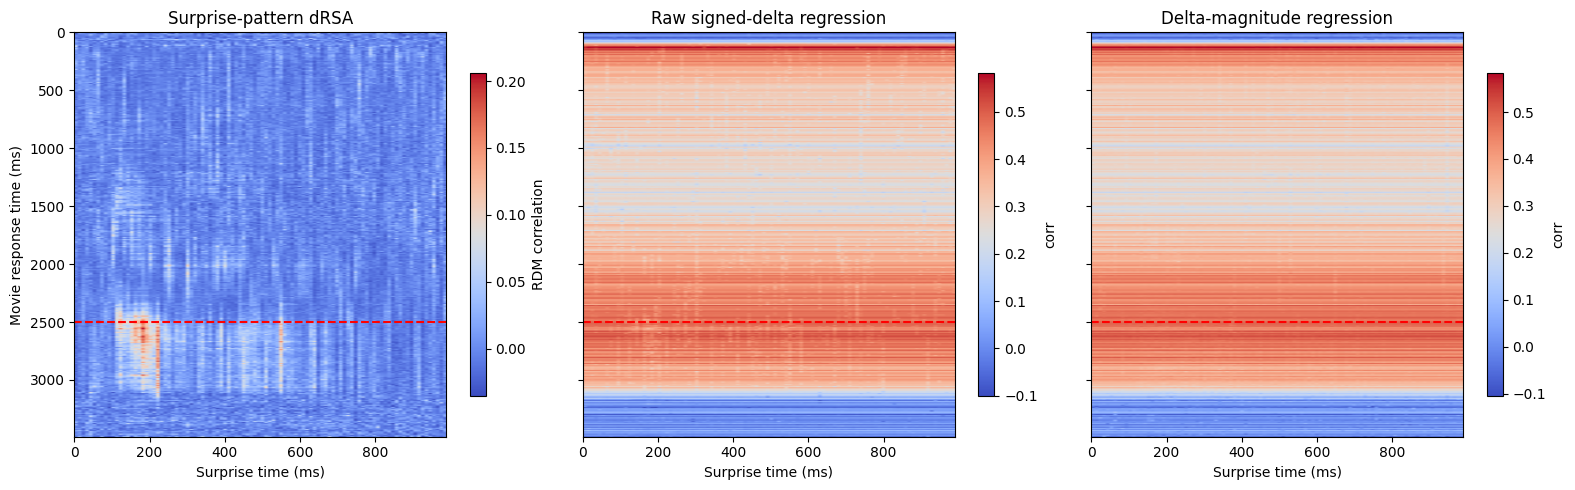

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
matrices = [
    surprise_drsa_matrix[
        ::cfg.movie_time_stride, ::cfg.surprise_time_stride
    ],
    raw_delta_regression_matrix,
    magnitude_regression_matrix,
]
titles = [
    "Surprise-pattern dRSA",
    "Raw signed-delta regression",
    "Delta-magnitude regression",
]
colorbar_labels = [
    "RDM correlation",
    cfg.regression_score_type,
    cfg.regression_score_type,
]

for axis, matrix, title, colorbar_label in zip(
        ax, matrices, titles, colorbar_labels,
        ):
    image = axis.imshow(
        matrix,
        aspect="auto",
        origin="upper",
        cmap="coolwarm",
        extent=[
            regression_surprise_time_ms[0],
            regression_surprise_time_ms[-1],
            regression_movie_time_ms[-1],
            regression_movie_time_ms[0],
        ],
    )
    if (
            regression_movie_time_ms[0]
            <= cfg.movie_final_frame_ms
            <= regression_movie_time_ms[-1]
            ):
        axis.axhline(
            cfg.movie_final_frame_ms, color="red", linestyle="--",
        )
    # end if cfg.movie_final_frame_ms
    axis.set_title(title)
    axis.set_xlabel("Surprise time (ms)")
    fig.colorbar(image, ax=axis, label=colorbar_label, shrink=0.8)
# end for axis, matrix, title, colorbar_label

ax[0].set_ylabel("Movie response time (ms)")
fig.tight_layout()


## Interpretation notes

- The dRSA matrix asks whether the **geometry of stimulus differences** in the movie resembles the geometry of the static-condition surprise.
- Raw-delta regression asks whether the signed multichannel surprise pattern predicts the movie population pattern across held-out stimuli.
- Magnitude regression asks whether overall surprise strength alone predicts that movie pattern.
- These statistics have matching time axes but different numerical meanings; their values should not be compared as if they shared a scale.
- The analysis is predictive, not causal. Cross-validation limits in-sample overfitting but does not establish that surprise drives the movie response.